# Boundary optimization analysis

This notebook analyses the results of AkitaSF boundary sequence design across four target insulation score strengths (−0.2, −0.3, −0.4, −0.5), and additionally explores optimization behaviour at more extreme targets (−0.5, −1.0, −5.0).

**Analysis overview:**
1. Load and pre-process optimization results across all targets and folds.
2. Summarise per-target optimization statistics (success rate, edit counts).
3. Compare insulation scores of designed sequences against the pre-optimization baseline and natural boundaries.
4. Examine how CTCF binding site counts change between the original and designed sequences.
5. Characterise the CTCF orientation patterns found in successfully designed sequences.
6. Explore behaviour at extreme targets (−1.0, −5.0).

## 1. Imports

In [1]:
import os
import sys

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))

from utils.df_utils import load_optimization_results, summarize_by_target

## 2. Configuration

In [2]:
BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/results/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

NATURAL_BOUNDARIES_PATH = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/natural_features/boundaries/mouse_natural_boundaries_strength.tsv")

RESULT_DIRS = ["boundary_neg0p2", "boundary_neg0p3", "boundary_neg0p4", "boundary_neg0p5"]
TARGETS     = [-0.2, -0.3, -0.4, -0.5]
FOLDS       = range(8)

## 3. Load and pre-process optimization results

Results are loaded from per-fold TSV files across all four target directories.
An optimization run is defined as **successful** if the edited sequence has a lower predicted insulation score than the original sequence, i.e. `insul_score_edited < insul_score_orig`.

In [3]:
df = load_optimization_results(RESULT_DIRS, BASE_DIR, FOLDS)

df["insul_score_diff"]     = df["insul_score_edited"] - df["insul_score_orig"]
df["optimization_success"] = df["insul_score_diff"] < 0

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds and {df['target'].nunique()} targets")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)} ({100 * df['optimization_success'].mean():.1f}%)")

Loaded 1420 windows across 8 folds and 4 targets
Successful optimizations: 1281 / 1420 (90.2%)


## 4. Per-target optimization summary

For each target we report:
- **n_no_edits** — runs where the optimizer accepted zero edits (immediately stuck).
- **n_no_depletion** — runs where edits were made but the insulation score did not decrease.
- **success_rate_pct** — percentage of runs that achieved a lower insulation score.

For successful runs only:
- **mean_n_edits** — average number of accepted sequence edits.
- **mean_last_step** — average optimization step at which the last edit was accepted.

In [4]:
summary = summarize_by_target(df)
summary

,target,n_total,n_no_edits,n_no_depletion,success_rate_pct,mean_n_edits,mean_last_step
0,-0.5,355,32,0,91.0,55.6,1956.4
1,-0.4,355,41,0,88.5,42.8,1958.7
2,-0.3,355,28,0,92.1,31.4,1947.3
3,-0.2,355,38,0,89.3,23.2,1955.8


## 5. Insulation score distributions

We compare insulation scores across three groups:
1. **Before optimization** — original predicted insulation scores of the flat genomic windows used as starting sequences.
2. **Designed sequences** — predicted insulation scores after optimization, shown separately for each target strength.
3. **Natural boundaries** — insulation scores of real TAD boundaries in mouse (mm10, Hsieh2019 mESC), estimated with the URQ metric.

Only successfully optimized sequences are included in groups 1 and 2. A lower insulation score indicates a stronger predicted boundary.

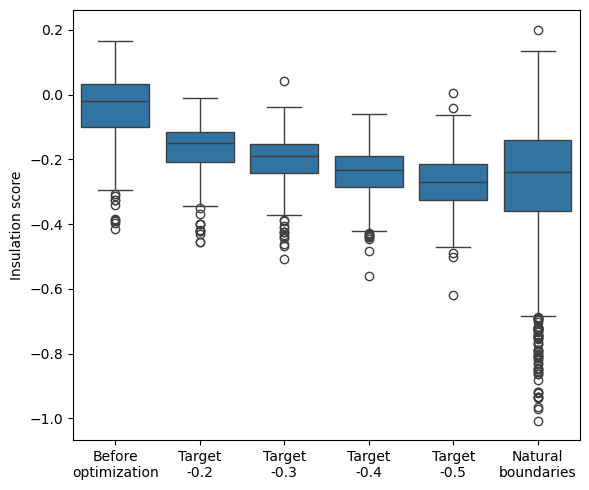

In [5]:
nat_df = pd.read_csv(NATURAL_BOUNDARIES_PATH, sep="\t")

successful = df[df["optimization_success"]]

parts = []

# (1) Original insulation scores — one target only to avoid duplicate windows
orig_scores = successful[successful["target"] == TARGETS[0]][["insul_score_orig"]].copy()
orig_scores["group"] = "Before\noptimization"
orig_scores = orig_scores.rename(columns={"insul_score_orig": "insul_score"})
parts.append(orig_scores)

# (2) Edited insulation scores per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["insul_score_edited"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"insul_score_edited": "insul_score"})
    parts.append(edited)

# (3) Natural boundary insulation scores
nat_scores = nat_df[["URQ_mean"]].copy()
nat_scores["group"] = "Natural\nboundaries"
nat_scores = nat_scores.rename(columns={"URQ_mean": "insul_score"})
parts.append(nat_scores)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS] + ["Natural\nboundaries"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=plot_df, x="group", y="insul_score", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Insulation score")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "insulation_scores_boxplot.svg", format="svg")
plt.show()

## 6. CTCF binding site counts

CTCF motif hits are detected with FIMO across the designed sequence window. We compare the number of CTCF binding sites before and after optimization for each target.
An increase in CTCF count would be consistent with the optimizer inserting or strengthening CTCF motifs to create a boundary.

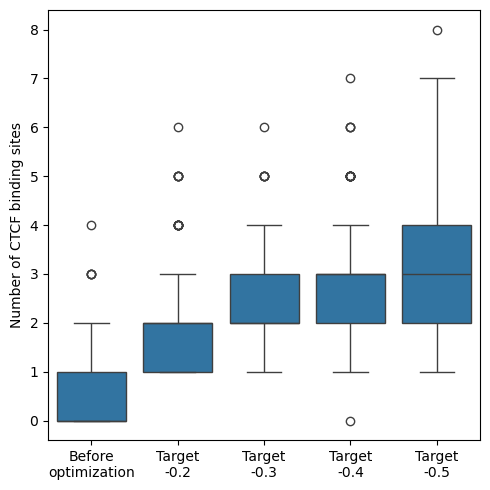

In [6]:
parts = []

# (1) Initial CTCF counts — one target only to avoid duplicate windows
orig_ctcf = successful[successful["target"] == TARGETS[0]][["init_CTCFs_num"]].copy()
orig_ctcf["group"] = "Before\noptimization"
orig_ctcf = orig_ctcf.rename(columns={"init_CTCFs_num": "n_CTCFs"})
parts.append(orig_ctcf)

# (2) Edited CTCF counts per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["CTCFs_num"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"CTCFs_num": "n_CTCFs"})
    parts.append(edited)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=plot_df, x="group", y="n_CTCFs", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Number of CTCF binding sites")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "ctcf_counts_boxplot.svg", format="svg")
plt.show()

## 7. CTCF orientation patterns

TAD boundaries are established by pairs of convergently oriented CTCF sites that act as loop extrusion barriers. We examine which CTCF orientation combinations (e.g. `+`, `+-`, `-+`, `++--`) appear in the successfully designed sequences across all targets.

Only orientations observed more than 10 times are shown to focus on recurring patterns.

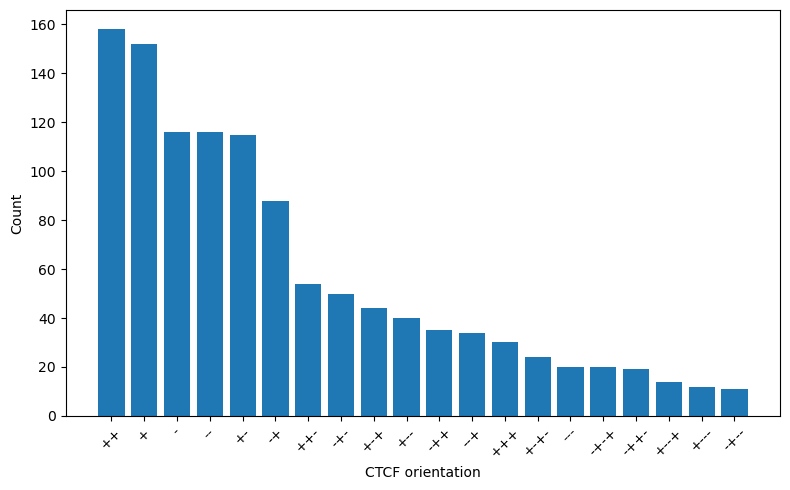

In [7]:
orientation_counts = successful["orientation"].value_counts()
orientation_counts = orientation_counts[orientation_counts > 10].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(orientation_counts.index, orientation_counts.values)
ax.set_xlabel("CTCF orientation")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "ctcf_orientation_histogram.svg", format="svg")
plt.show()

## 8. Extreme targets analysis

In the previous sections we analysed targets in the range −0.2 to −0.5, which represent moderate boundary strengths.
Here we push the optimizer towards more extreme target insulation scores (−1.0, −5.0) to probe the limits of what AkitaSF can design.

Key questions:
- Does the success rate drop as targets become more extreme?
- Do designed sequences require more edits to approach harder targets?
- How do the resulting insulation scores and CTCF counts compare to natural boundaries?

In [8]:
RESULT_DIRS_EXT = ["boundary_neg0p5", "boundary_neg1p0", "boundary_neg5p0"]
TARGETS_EXT     = [-0.5, -1.0, -5.0]
FOLDS           = range(8)

In [9]:
df_ext = load_optimization_results(RESULT_DIRS_EXT, BASE_DIR, FOLDS)

df_ext["insul_score_diff"]     = df_ext["insul_score_edited"] - df_ext["insul_score_orig"]
df_ext["optimization_success"] = df_ext["insul_score_diff"] < 0

print(f"Loaded {len(df_ext)} windows across {df_ext['fold'].nunique()} folds and {df_ext['target'].nunique()} targets")
print(f"Successful optimizations: {df_ext['optimization_success'].sum()} / {len(df_ext)} ({100 * df_ext['optimization_success'].mean():.1f}%)")

Loaded 1065 windows across 8 folds and 3 targets
Successful optimizations: 935 / 1065 (87.8%)


### 8.1 Per-target summary

Same metrics as in section 4 — success rate, failed runs, and edit statistics for successful runs.

In [10]:
summary_ext = summarize_by_target(df_ext)
summary_ext

,target,n_total,n_no_edits,n_no_depletion,success_rate_pct,mean_n_edits,mean_last_step
0,-5.0,355,50,0,85.9,124.8,1964.6
1,-1.0,355,48,0,86.5,112.8,1963.7
2,-0.5,355,32,0,91.0,55.6,1956.4


### 8.2 Insulation score distributions

Insulation scores of successfully designed sequences at each extreme target, compared to the pre-optimization baseline and natural boundary scores.
This shows how close the optimizer gets to the target and whether scores at the hardest targets (−1.0, −5.0) approach or exceed what is seen in natural boundaries.

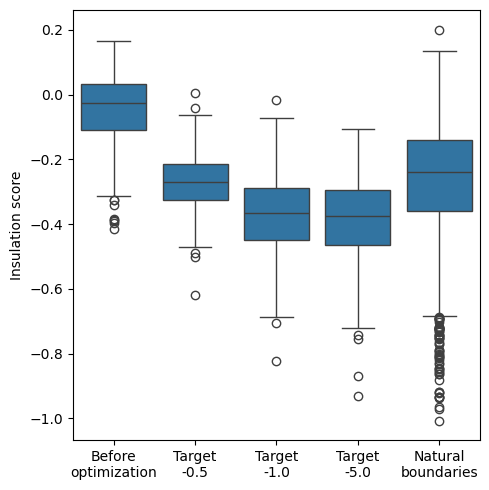

In [11]:
nat_df_ext = pd.read_csv(NATURAL_BOUNDARIES_PATH, sep="\t")

successful_ext = df_ext[df_ext["optimization_success"]]

parts = []

orig_scores = successful_ext[successful_ext["target"] == TARGETS_EXT[0]][["insul_score_orig"]].copy()
orig_scores["group"] = "Before\noptimization"
orig_scores = orig_scores.rename(columns={"insul_score_orig": "insul_score"})
parts.append(orig_scores)

for target in TARGETS_EXT:
    edited = successful_ext[successful_ext["target"] == target][["insul_score_edited"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"insul_score_edited": "insul_score"})
    parts.append(edited)

nat_scores = nat_df_ext[["URQ_mean"]].copy()
nat_scores["group"] = "Natural\nboundaries"
nat_scores = nat_scores.rename(columns={"URQ_mean": "insul_score"})
parts.append(nat_scores)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS_EXT] + ["Natural\nboundaries"]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=plot_df, x="group", y="insul_score", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Insulation score")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "extreme_insulation_scores_boxplot.svg", format="svg")
plt.show()

### 8.3 CTCF binding site counts

We examine whether the optimizer places more CTCF sites when targeting more extreme insulation scores, which would suggest it relies on stronger or more numerous CTCF anchors to achieve harder boundary strengths.

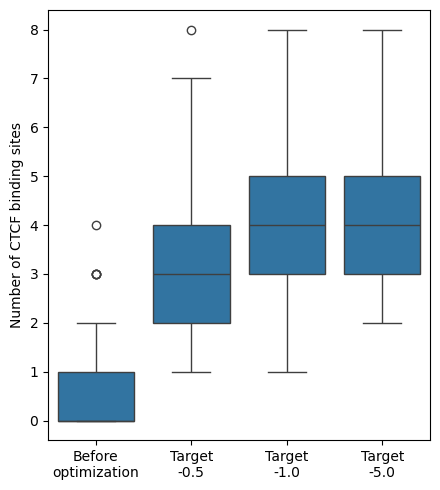

In [12]:
parts = []

orig_ctcf = successful_ext[successful_ext["target"] == TARGETS_EXT[0]][["init_CTCFs_num"]].copy()
orig_ctcf["group"] = "Before\noptimization"
orig_ctcf = orig_ctcf.rename(columns={"init_CTCFs_num": "n_CTCFs"})
parts.append(orig_ctcf)

for target in TARGETS_EXT:
    edited = successful_ext[successful_ext["target"] == target][["CTCFs_num"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"CTCFs_num": "n_CTCFs"})
    parts.append(edited)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS_EXT]

fig, ax = plt.subplots(figsize=(4.5, 5))
sns.boxplot(data=plot_df, x="group", y="n_CTCFs", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Number of CTCF binding sites")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "extreme_ctcf_counts_boxplot.svg", format="svg")
plt.show()